In [ ]:
import numpy as np
def generate_gbm_paths(S0, r, sigma, T, M, N, seed=20):
    """Generate Geometric Brownian Motion paths."""
    np.random.seed(seed)
    dt = T / M
    drift = (r - 0.5 * sigma ** 2) * dt
    diffusion = sigma * np.sqrt(dt) * np.random.normal(size=(M, N))
    log_returns = drift + diffusion
    log_prices = np.cumsum(log_returns, axis=0)
    log_prices = np.vstack((np.zeros(N), log_prices))
    return S0 * np.exp(log_prices)

def least_squares_monte_carlo(S0, K, r, sigma, T, M, N, option_type='call', seed=20):
    """Price American options using Least Squares Monte Carlo."""
    dt = T / M
    discount_factor = np.exp(-r * dt)
    paths = generate_gbm_paths(S0, r, sigma, T, M, N, seed=seed)
    payoffs = np.maximum(paths[-1] - K, 0) if option_type == 'call' else np.maximum(K - paths[-1], 0)

    for t in range(M - 1, 0, -1):
        in_the_money = np.where((paths[t] > K) if option_type == 'call' else (paths[t] < K))[0]
        if len(in_the_money) == 0:
            continue

        X = paths[t, in_the_money]
        Y = payoffs[in_the_money] * discount_factor

        if len(X) > 2:
            X_norm = (X - X.mean()) / X.std()
            try:
                coeffs = np.polyfit(X_norm, Y, deg=2)
                continuation_values = np.polyval(coeffs, (X - X.mean()) / X.std())
            except np.RankWarning:
                continuation_values = np.zeros_like(X)
        else:
            continuation_values = np.zeros_like(X)

        exercise_values = (X - K) if option_type == 'call' else (K - X)
        payoffs[in_the_money] = np.where(exercise_values > continuation_values,
                                        exercise_values,
                                        payoffs[in_the_money]) * discount_factor

    return np.mean(payoffs) * np.exp(-r * T)
lsm_call_price = least_squares_monte_carlo(
            S0=602.8, K=610, r=0.0423,
             sigma=0.1211, T=3/252,
            M=100, N=10000, option_type='call', seed=20
        )
print(lsm_call_price)


0.8839442068385834


In [ ]:
import yfinance as yf
import numpy as np

def calculate_spy_volatility():
    """
    Calculates the annualized volatility of SPY over the last year.

    Returns:
    - annualized_volatility (float): Annualized volatility of SPY as a percentage.
    """
    # Fetch SPY historical price data for the last 1 year
    spy = yf.Ticker("SPY")
    hist = spy.history(period="1y", interval="1d")

    # Check if data is fetched
    if hist.empty:
        print("Could not fetch data for SPY. Please check your internet connection or ticker symbol.")
        return None

    # Calculate daily returns
    hist['Daily Return'] = hist['Close'].pct_change()

    # Drop NaN values from the return series
    daily_returns = hist['Daily Return'].dropna()

    # Compute annualized volatility: std deviation of daily returns * sqrt(252)
    annualized_volatility = np.std(daily_returns) * np.sqrt(252) * 100  # Percentage

    return annualized_volatility

# Example usage
volatility = calculate_spy_volatility()
if volatility:
    print(f"Annualized Volatility of SPY (Last 1 Year): {volatility:.2f}%")
else:
    print("Failed to calculate volatility.")


Annualized Volatility of SPY (Last 1 Year): 12.11%


In [ ]:
import pandas as pd
import numpy as np

# Define the start and end dates
start_date = "2024-12-11"
end_date = "2025-03-21"

# Generate a date range and filter for weekdays (Monday to Friday)
all_dates = pd.date_range(start=start_date, end=end_date, freq='B')

# Count the number of business days
trading_days = len(all_dates)

print(f"Number of trading days between {start_date} and {end_date}: {trading_days}")


Number of trading days between 2024-12-11 and 2025-03-21: 73


In [ ]:
import numpy as np
S0 = 607.8
def generate_gbm_paths(S0, r, sigma, T, M, N, seed=20):
    """Generate Geometric Brownian Motion paths."""
    np.random.seed(seed)
    dt = T / M
    drift = (r - 0.5 * sigma ** 2) * dt
    diffusion = sigma * np.sqrt(dt) * np.random.normal(size=(M, N))
    log_returns = drift + diffusion
    log_prices = np.cumsum(log_returns, axis=0)
    log_prices = np.vstack((np.zeros(N), log_prices))
    return S0 * np.exp(log_prices)

def least_squares_monte_carlo(S0, K, r, sigma, T, M, N, option_type='call', seed=20):
    """Price American options using Least Squares Monte Carlo."""
    dt = T / M
    discount_factor = np.exp(-r * dt)
    paths = generate_gbm_paths(S0, r, sigma, T, M, N, seed=seed)
    payoffs = np.maximum(paths[-1] - K, 0) if option_type == 'call' else np.maximum(K - paths[-1], 0)

    for t in range(M - 1, 0, -1):
        in_the_money = np.where((paths[t] > K) if option_type == 'call' else (paths[t] < K))[0]
        if len(in_the_money) == 0:
            continue

        X = paths[t, in_the_money]
        Y = payoffs[in_the_money] * discount_factor

        if len(X) > 2:
            X_norm = (X - X.mean()) / X.std()
            try:
                coeffs = np.polyfit(X_norm, Y, deg=2)
                continuation_values = np.polyval(coeffs, (X - X.mean()) / X.std())
            except np.RankWarning:
                continuation_values = np.zeros_like(X)
        else:
            continuation_values = np.zeros_like(X)

        exercise_values = (X - K) if option_type == 'call' else (K - X)
        payoffs[in_the_money] = np.where(exercise_values > continuation_values,
                                        exercise_values,
                                        payoffs[in_the_money]) * discount_factor

    return np.mean(payoffs) * np.exp(-r * T)

def compute_american_option_greeks(S0, K, r, sigma, T, M=100, N=10000, option_type='call', epsilon=0.001*S0):
    """
    Compute Greeks for American Options using Numerical Differentiation

    Parameters:
    - S0: Current stock price
    - K: Strike price
    - r: Risk-free rate
    - sigma: Volatility
    - T: Time to maturity
    - M: Number of time steps
    - N: Number of Monte Carlo paths
    - option_type: 'call' or 'put'
    - epsilon: Perturbation for numerical differentiation

    Returns:
    Dictionary of Greeks: Price, Delta, Gamma, Theta, Vega
    """
    # Base Option Price
    base_price = least_squares_monte_carlo(S0, K, r, sigma, T, M, N, option_type)

    # Delta Computation: ∂Price/∂S0
    delta_plus = least_squares_monte_carlo(S0 + epsilon, K, r, sigma, T, M, N, option_type)
    delta_minus = least_squares_monte_carlo(S0 - epsilon, K, r, sigma, T, M, N, option_type)
    delta = (delta_plus - delta_minus) / (2 * epsilon)

    # Gamma Computation: ∂²Price/∂S0²
    gamma_plus = least_squares_monte_carlo(S0 + epsilon, K, r, sigma, T, M, N, option_type)
    gamma_minus = least_squares_monte_carlo(S0 - epsilon, K, r, sigma, T, M, N, option_type)
    gamma = (gamma_plus - 2 * base_price + gamma_minus) / (epsilon ** 2)

    # Theta Computation: -∂Price/∂T
    theta_plus = least_squares_monte_carlo(S0, K, r, sigma, T + epsilon, M, N, option_type)
    theta = -(theta_plus - base_price) / epsilon

    # Vega Computation: ∂Price/∂σ
    vega_plus = least_squares_monte_carlo(S0, K, r, sigma + epsilon, T, M, N, option_type)
    vega = (vega_plus - base_price) / epsilon

    return {
        'Price': base_price,
        'Delta': delta,
        'Gamma': gamma,
        'Theta': theta,
        'Vega': vega
    }

# Example Usage
if __name__ == "__main__":
    # SPY Option Example Parameters
    S0 = 607.659973
    K = 600    # Strike Price

    r = 0.0425     # Risk-free Rate
    sigma = 0.1219 # Volatility
    T = 27/252     # Time to Maturity (1 year)
    M=100
    N=10000
    # Compute Greeks
    american_call_greeks = compute_american_option_greeks(S0, K, r, sigma, T, option_type='call')
    american_put_greeks = compute_american_option_greeks(S0, K, r, sigma, T, option_type='put')
    base_price = least_squares_monte_carlo(S0, K, r, sigma, T, M, N, option_type='call')
    print("American Call Option Greeks:")
    for greek, value in american_call_greeks.items():
        print(f"{greek}: {value}")

    print("\nAmerican Put Option Greeks:")
    for greek, value in american_put_greeks.items():
        print(f"{greek}: {value}")

American Call Option Greeks:
Price: 15.493512268460046
Delta: 0.6613450210716112
Gamma: -0.33112151178928156
Theta: -38.23740296234189
Vega: 77.98398579125481

American Put Option Greeks:
Price: 5.269675448986043
Delta: -0.3389581978074615
Gamma: -0.053807782187457576
Theta: -15.164970007123776
Vega: 75.32886419682886


        date        spot     delta  call_price  delta_hedge  portfolio_value  \
0 2024-12-04  607.659973  0.661345   15.493510      0.00000     -1549.351000   
1 2024-12-05  606.659973  0.647738   14.782739   -136.07000     81069.948579   
2 2024-12-06  607.809998  0.734539   15.562377    868.01000   -446593.171538   
3 2024-12-09  604.679993  0.607965   13.591060  -1265.73900    318971.009822   
4 2024-12-10  602.799988  0.610771   12.430600     28.06134    302171.680407   

   delta_change  cost_of_hedge  portfolio_change  
0       0.00000       0.000000          0.000000  
1    -136.07000  -82548.222526      82619.299579  
2     868.01000  527585.156364    -527663.120117  
3   -1265.73900 -765367.049660     765564.181360  
4      28.06134   16915.375415     -16799.329415  


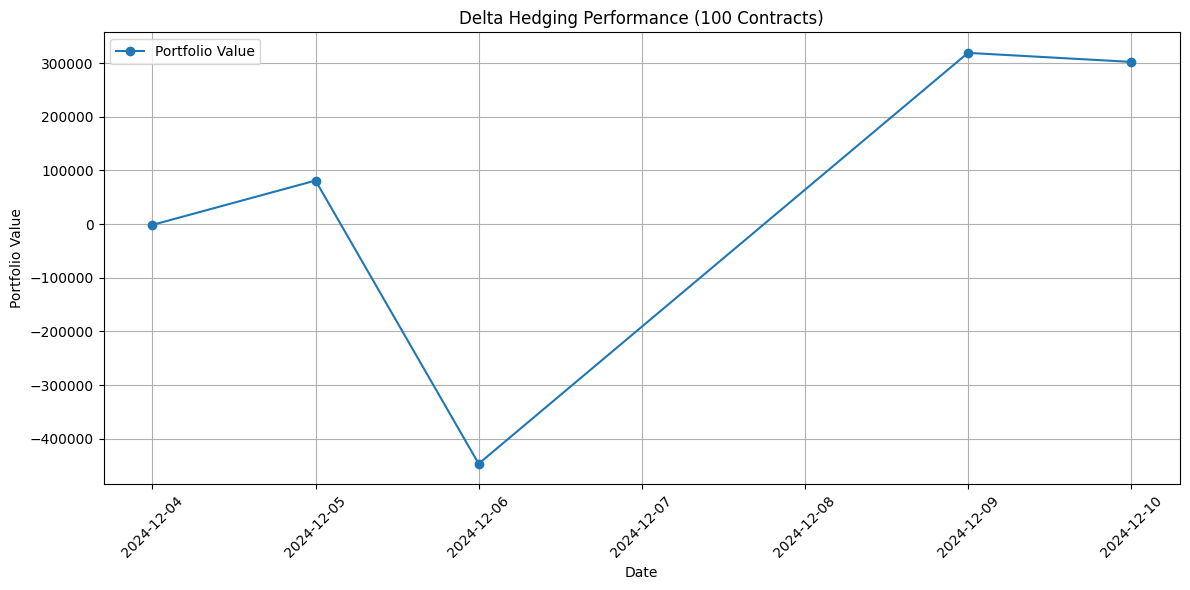

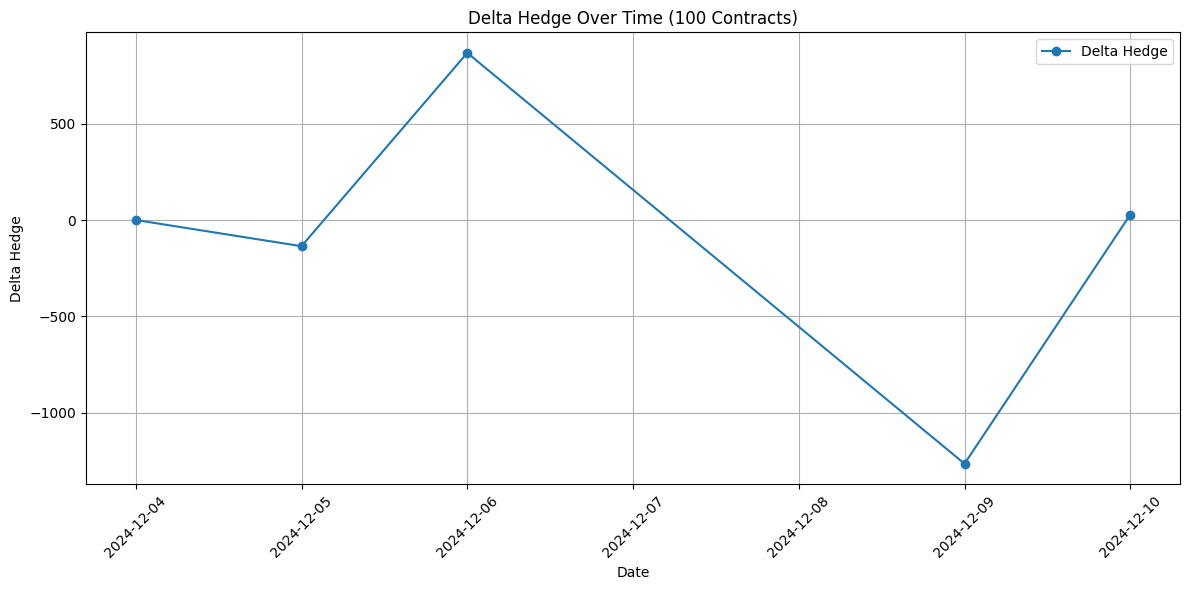

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {'date': pd.to_datetime(['2024-12-04', '2024-12-05', '2024-12-06', '2024-12-09', '2024-12-10']),
        'spot': [607.659973, 606.659973, 607.809998, 604.679993, 602.799988],
        'delta': [0.661345, 0.647738, 0.734539, 0.6079651, 0.610771234],
        'call_price': [15.49351, 14.782739470224, 15.562377, 13.59106, 12.4306]}

df = pd.DataFrame(data)

num_contracts = 100  # Number of option contracts (each contract represents 100 shares)

df['delta_hedge'] = 0.0
df['portfolio_value'] = 0.0
df['delta_change'] = 0.0
df['cost_of_hedge'] = 0.0
df['portfolio_change'] = 0.0

# Initial position: Short 100 call options
df.loc[0, 'portfolio_value'] = -num_contracts * df['call_price'][0]

for i in range(1, len(df)):
    # Calculate delta change (multiplied by the number of contracts * 100 shares/contract)
    df.loc[i, 'delta_change'] = (df['delta'][i] - df['delta'][i-1]) * num_contracts * 100

    # Calculate the number of shares to buy/sell for delta hedging
    df.loc[i, 'delta_hedge'] = df['delta_change'][i]

    # Cost of hedging
    df.loc[i, 'cost_of_hedge'] = df['delta_hedge'][i] * df['spot'][i]

    # Change in portfolio value due to option price change (multiplied by number of contracts)
    option_price_change = (df['call_price'][i] - df['call_price'][i-1]) * num_contracts

    # Change in portfolio value due to hedging
    df.loc[i, 'portfolio_change'] = -option_price_change - df['cost_of_hedge'][i]

    # Update the portfolio value
    df.loc[i, 'portfolio_value'] = df['portfolio_value'][i-1] + df['portfolio_change'][i]

print(df)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['portfolio_value'], marker='o', label='Portfolio Value')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title(f'Delta Hedging Performance ({num_contracts} Contracts)') #Updated Title
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['delta_hedge'], marker='o', label='Delta Hedge')
plt.xlabel('Date')
plt.ylabel('Delta Hedge')
plt.title(f'Delta Hedge Over Time ({num_contracts} Contracts)') #Updated Title
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
|import yfinance as yf
expiration_date = "2025-01-10"
strike=K
def get_actual_option_price(ticker, strike, expiration):
    # Fetch the SPY options chain for a given expiration date
    spy = yf.Ticker(ticker)
    options_chain = spy.option_chain(expiration)

    # Get the calls and puts for the expiration
    calls = options_chain.calls
    puts = options_chain.puts

    # Find the closest strike price
    actual_call_price = calls[calls['strike'] == strike]['lastPrice'].values
    actual_put_price = puts[puts['strike'] == strike]['lastPrice'].values
    print(actual_put_price)
    # If the option exists, return the price
    if len(actual_call_price) > 0:
        return actual_call_price[0], 'call'
    elif len(actual_put_price) > 0:
        return actual_put_price[0], 'put'
    else:
        raise ValueError("Option with the given strike price not found.")
expiration_date = "2025-01-10"  # Expiration date for SPY options (adjust as needed)
try:
    actual_price, option_type = get_actual_option_price("SPY", K, expiration_date)
    error = abs( base_price- actual_price)
    print(f"LSMC American Option Price: {base_price:.2f}")
    print(f"Actual Option Price: {actual_price:.2f}")
    print(f"Error: {error:.2f}")
except ValueError as e:
    print(e)

[2.51]
LSMC American Option Price: 23.46
Actual Option Price: 21.25
Error: 2.21


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

# Fetch SPY historical data
ticker = "SPY"
start_date = "2023-12-01"  # Specify start date
end_date = "2024-12-01"    # Specify end date

# Download historical data from Yahoo Finance
spy_data = yf.download(ticker, start=start_date, end=end_date)

# Calculate daily returns
spy_data['Daily Return'] = spy_data['Adj Close'].pct_change()

# Compute daily volatility (standard deviation of returns)
daily_volatility = spy_data['Daily Return'].std()

# Annualize the volatility (assuming 252 trading days per year)
annualized_volatility = daily_volatility * np.sqrt(252)

# 1-Month Period: 11 Dec 2024 to 17 Jan 2025
start_date_1m = "2024-12-11"
end_date_1m = "2025-01-17"
volatility_1m = calculate_historical_volatility(ticker, start_date_1m, end_date_1m)
print(f"1-Month Annualized Volatility (11 Dec 2024 to 17 Jan 2025): {volatility_1m:.4f}")

# 3-Month Period: 11 Dec 2024 to 21 Mar 2025
start_date_3m = "2024-12-11"
end_date_3m = "2025-03-21"
volatility_3m = calculate_historical_volatility(ticker, start_date_3m, end_date_3m)
print(f"3-Month Annualized Volatility (11 Dec 2024 to 21 Mar 2025): {volatility_3m:.4f}")

print(f"Daily Volatility of SPY: {daily_volatility:.4f}")
print(f"Annualized Volatility of SPY: {annualized_volatility:.4f}")

 # Calculate 1-month and 3-month historical volatility
one_month_volatility = calculate_historical_volatility(price_data, "2024-12-11", "2025-01-17", 21)
three_month_volatility = calculate_historical_volatility(price_data, "2024-12-11", "2025-03-21", 63)

print(f"1-Month Volatility (Annualized): {one_month_volatility:.4f}")
print(f"3-Month Volatility (Annualized): {three_month_volatility:.4f}")


[*********************100%***********************]  1 of 1 completed

Daily Volatility of SPY: 0.0077
Annualized Volatility of SPY: 0.1219


TypeError: unsupported format string passed to NoneType.__format__